In [1]:
import sys

from sympy.codegen.ast import real

sys.executable
import os
print("Python executable:", sys.executable)
#print("Conda env:", os.environ.get("CONDA_DEFAULT_ENV"))
#print("Conda prefix:", os.environ.get("CONDA_PREFIX"))

Python executable: C:\Users\jigar\OneDrive\Documents\projects\qiskit\QuantumInformation-GeneralFormulation\QuantumInformation\QuantumInfoVenv\python.exe


In [2]:
import numpy as np
from typing import Dict, Iterable, Union
from numpy.typing import NDArray
import matplotlib.pyplot as plt

from qiskit.quantum_info import Statevector, DensityMatrix, partial_trace, Pauli

np.set_printoptions(precision=4, suppress=True)
MatrixLike = Union[np.array, DensityMatrix]

*************************Function-1*************************
[[1.+0.j 2.+0.j]
 [3.+0.j 4.+0.j]]
*************************Function-2*************************
TestMatrix:
[[1.+0.j 2.+0.j 3.+0.j]
 [3.+0.j 4.+0.j 5.+0.j]]
*************************Function-3*************************
True
False
*************************Function-4*************************
False
True
*************************Function-5*************************
(12+0j)
*************************Function-6*************************
[0.8+0.j 0.2+0.j]
[0.2+0.j 0.3+0.j 0.5+0.j]
*************************Function-7*************************
True
*************************Function-8*************************
True
*************************Function-9*************************
0.6799999999999999
*************************Function-10*************************
Report for DensityMatrix
DensityMatrix:
[[0.5+0.j  0. -0.3j]
 [0. +0.3j 0.5+0.j ]]
Hermitian?             True
Trace =                (1+0j)
Eigenvalues =          [0.8+0.j 0.2+0.j]
Positive

C:\Users\jigar\OneDrive\Documents\projects\qiskit\QuantumInformation-GeneralFormulation\QuantumInformation\QuantumInfoVenv\Lib\site-packages\qiskit\quantum_info\states\densitymatrix.py:118: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.array(self.data, dtype=dtype, copy=copy)


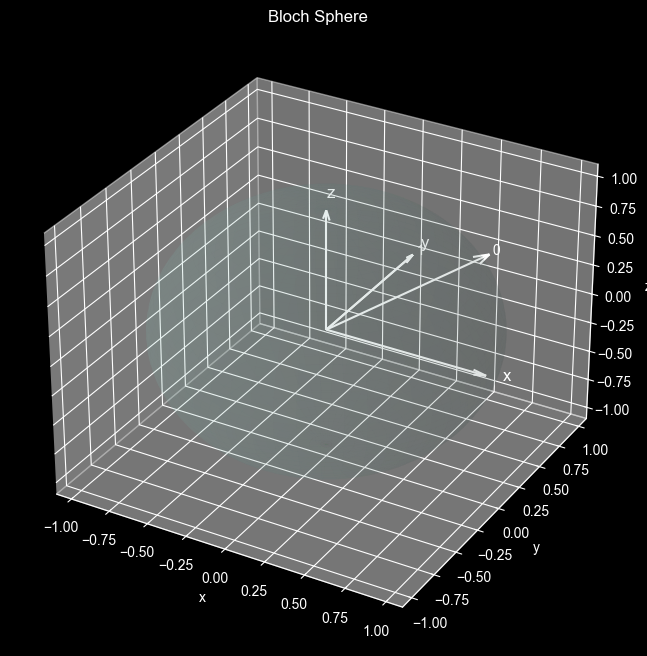

In [3]:
def to_numpy_matrix(matrix: MatrixLike) -> NDArray[np.complex128]:
    """
    input must be a DensityMatrix or a numpy array
    convert input array/matrix to array/matrix with dtype=complex
    :param matrix:
    :return: matrix(array) with dtype=complex
    """
    if isinstance(matrix, DensityMatrix):
        return np.array(matrix.data, dtype=complex)
    return np.array(matrix, dtype=complex)

def pretty_matrix(matrix:MatrixLike, name:str="Matrix", precision:int=4) -> None:
    """
    Print a matrix in a readable format
    :param matrix: input matrix
    :param name: assigned name of the matrix
    :param precision: decimal place used in printing
    :return: this function only prints the matrix
    """
    mat = to_numpy_matrix(matrix)
    with np.printoptions(precision=precision, suppress=True):
        print(f"{name}:\n{mat}")

def is_square_matrix(matrix:MatrixLike) -> bool:
    """
    check whether the matrix is square-matrix or not,
    and return True if it is

    :param matrix:
    :return: bool (true/false)

    NOTE:this is required as density matrix must always be square matrix
    """
    mat = to_numpy_matrix(matrix)
    return mat.ndim == 2 and mat.shape[0] == mat.shape[1]

def is_hermitian( matrix:MatrixLike, tolerance: float=1e-10) -> bool:
    """
    check if the matrix is Hermitian
    A = A-dagger(conjugate transpose of A)
    :param matrix:
    :param tolerance: simply floating point number
    :return: bool (true/false)

    NOTE: if the input matrix is not square matrix, ValueError will be raised, also a valid density
    matrix must be hermitian because observable probs must be real
    """
    mat = to_numpy_matrix(matrix)
    if not is_square_matrix(mat):
        raise ValueError("Hermiticity is only defined for square matrices")
    return np.allclose( mat, mat.conj().T, atol=tolerance)

def trace_of_matrix(matrix:MatrixLike) -> complex:
    """
    compute the trace of the matrix
    :param matrix:
    :return: trace of the matrix
    NOTE: for valid density matrix, the matrix should be square, and the final output of this function
    should have imagionary part as 0
    """
    mat = to_numpy_matrix(matrix)
    if not is_square_matrix(mat):
        raise ValueError("Trace is only defined for square matrices")
    return np.trace(mat)

def eigenvalues_of_matrix(matrix:MatrixLike) -> NDArray[np.float64]:
    """
    COmpute the eigenvalues of the matrix
    :param matrix: inout hermitian matrix (for example)
    :return: egvals of the input matrix

    NOTE: hermitian matrices, eigenvalues are real.
    A density martix must have non-negative eigenvalues. This guarantees that
    probabilities of each egstates are real
    """
    mat = to_numpy_matrix(matrix)
    if not is_square_matrix(mat):
        raise ValueError("Eigenvalues are only defined for square matrices")
    if not is_hermitian(mat):
        raise ValueError("This function expects a Hermitian matrix")
    return np.linalg.eigvals(mat)

def is_positive_semidefinite(matrix:MatrixLike, tolerance: float=1e-10) -> bool:
    """
    check the input matrix is positive semidefinite or not
    :param matrix:
    :param tol: floating point number
    :return: bool (true/false)
    NOTE: being PSD, gives the quantum probs positive real part
    """
    egvals = eigenvalues_of_matrix(matrix)
    return bool(np.all(egvals > -tolerance))

def is_valid_density_matrix(matrix: MatrixLike, tolerance: float = 1e-10) -> bool:
    """
    apply is_square_matrix, is_hermitian, and is_positive_semidefinite to finalize
    the matrix is valid density matrix or not
    hermiticity: A = A-dagger(conjugate transpose of A)
    Trace: trace(A) = sum(eigenvalues) := 1
    Positive semidefinite: eigenvalues >= -tol
    :param matrix:
    :param tol:
    :return: bool (true/false)
    """
    mat = to_numpy_matrix(matrix)
    if not is_square_matrix(mat):
        return False

    hermitian_check = is_hermitian(mat, tolerance=tolerance)
    trace_check = np.isclose(trace_of_matrix(mat), 1, atol=tolerance)
    psd_check = is_positive_semidefinite(mat, tolerance=tolerance)

    return bool(hermitian_check and trace_check and psd_check)

def purity(matrix:MatrixLike) -> float:
    """
    compute the purity of a quantum state
    :param matrix:
    :return:  purity value
    NOTE: the purity of a quantum state is the probability of measuring the state itself
    wA pure state means we know the quantum state completely
    e.g, |0><0| has purity 1
    """
    rho = to_numpy_matrix(matrix)
    if not is_square_matrix(rho):
        raise ValueError("Purity is only defined for square matrices")
    value = np.trace(rho @ rho)
    return float(np.real_if_close(value))

def report_density_matrix(matrix:MatrixLike, name: str="DensityMatrix", tolerance: float=1e-10) -> None:
    """
    THe eintire diagnostic report of an input matrix, a test of density matrix or not
    :param matrix: matrix to be tested
    :param name: matrix name
    :param tolerance: number tolerance
    :return:
    NOTE: it includes
    - Matrix entries
    - Hermiticity check
    - Trace
    - Eigenvalues
    - Positive semidefinite check
    - Density matrix validity check
    - Purity
    """
    rho = to_numpy_matrix(matrix)
    print("=" * 60)
    print(f"Report for {name}")
    print("=" * 60)
    pretty_matrix(rho, name)
    print(f"Hermitian?             {is_hermitian(rho, tolerance=tolerance)}")
    print(f"Trace =                {trace_of_matrix(rho)}")
    print(f"Eigenvalues =          {eigenvalues_of_matrix(rho)}")
    print(f"Positive semidef.?     {is_positive_semidefinite(rho, tolerance=tolerance)}")
    print(f"Valid density matrix?  {is_valid_density_matrix(rho, tolerance=tolerance)}")
    print(f"Purity Tr(rho^2) =     {purity(rho)}")
    print()

def density_from_label_one_qubit(label:str) -> DensityMatrix:
    """
    Give standard state label and get 1-qubit density matrix
    :param label:
    :return:
    """
    state_map: Dict[str, Statevector] = {
        "0": Statevector.from_label("0"),
        "1": Statevector.from_label("1"),
        "+": Statevector.from_label("+"),
        "-": Statevector.from_label("-"),
        "r": Statevector.from_label("r"),
        "l": Statevector.from_label("l"),
    }
    if label not in state_map:
        supported = ", ".join(state_map.keys())
        raise ValueError(f"Unsupported label {label}, supported labels are {supported}")
    return DensityMatrix(state_map[label])

def densityMatrix_from_label(label:str) -> DensityMatrix:
    """
    Create a density matrix from qiskit state label
    :param label:
    "0","1","+","-","r","l", "00","01","10","11","rr","rl","ll","lr",
    "rl","rr","ll","lr","rrl","rrr","lll","llr","lll","llr","rrrl","rrrr"
    "000","001","010","011","100","101","110","111
    :return: DensityMatrix |psi><psi|
    """
    label = label.strip().lower()
    try:
        state = Statevector.from_label(label)
    except Exception as e:
        raise ValueError(
            f"Unsupported state label: {label!r}. "
            "Examples: '0', '00', '000', '0000', '00000', '000000', '0000000', '00000000', "
        ) from e
    return DensityMatrix(state)

def measurement_probabilities_standard_basis_1qubit(matrix:MatrixLike) -> NDArray[np.float64]:
    """
    calculate probs for 1-qubit density matrix
    :param matrix: input matrix
    :return: array of probabilities
    NOTE: for 1-qubit density matrix, the probabilities are simply the diagonal elements
    """
    rho = to_numpy_matrix(matrix)
    if rho.shape != (2, 2):
        raise ValueError("Input matrix must be a 2x2 square matrix")
    probabilities = np.real_if_close(np.diag(rho))
    return np.array(probabilities, dtype=float)

def is_power_of_two(number:int) -> bool:
    """
    check whether the input number is power of 2 or not
    :param number:
    :return:
    """
    return number > 0 and (number & (number - 1)) == 0

def measurement_probabilities_standard_basis(matrix:MatrixLike) -> NDArray[np.float64]:
    """
    calculate probs for 1-qubit density matrix
    :param matrix: input matrix
    :return: array of probabilities
    NOTE: for 1-qubit density matrix, the probabilities are simply the diagonal elements
    """
    rho = to_numpy_matrix(matrix)
    if not is_square_matrix(rho):
        raise ValueError("Input matrix must be a square matrix")
    dimension = rho.shape[0]
    if not is_power_of_two(dimension):
        raise ValueError(" A multi-qubit density matrix must have dimension 2**n X 2**n"
                         f" but got {dimension}x{dimension}")
    probabilities = np.real_if_close(np.diag(rho))
    return np.array(probabilities, dtype=float)

def bloch_vector(matrix:MatrixLike) -> NDArray[np.float64]:
    """
    compute bloch vector of 1-qubit density matrix
    :param matrix: matrix
    :return: bloch vector
    NOTE: any bloch vector for 1 qubit density matrix cab be written as
    rho = 0.5 * (I + rx X + ry Y + rz Z)
    rx = Tr(rho x), ry = Tr(rho y), rz = Tr(rho z)
    Pure stated lie on the surface of bloch sphere, mixed state li inside the sphere
    """
    rho = to_numpy_matrix(matrix)
    if rho.shape != (2, 2):
        raise ValueError("Input matrix must be a 2x2 square matrix")
    X = Pauli("X").to_matrix()
    Y = Pauli("Y").to_matrix()
    Z = Pauli("Z").to_matrix()
    rx = np.trace(rho @ X)
    ry = np.trace(rho @ Y)
    rz = np.trace(rho @ Z)
    return np.array([
        float(np.real_if_close(rx)), float(np.real_if_close(ry)), float(np.real_if_close(rz))
    ], dtype=float)

def plot_bloch_vectors(named_vectors: Dict[str, Iterable[float]], title: "Bloch Sphere") -> None:
    """
    plot one or more bloch vectors on a Bloch sphere
    :param named_vectors:
    :param title:
    :return:
    """
    fig = plt.figure(figsize=(8, 8))
    ax = fig.add_subplot(111, projection="3d")

    # Draw transparent Bloch sphere surface
    u = np.linspace(0, 2 * np.pi, 100)
    v = np.linspace(0, np.pi, 100)

    x = np.outer(np.cos(u), np.sin(v))
    y = np.outer(np.sin(u), np.sin(v))
    z = np.outer(np.ones_like(u), np.cos(v))

    ax.plot_surface(x, y, z, alpha=0.08, linewidth=0)

    # Draw coordinate axes
    ax.quiver(0, 0, 0, 1, 0, 0, arrow_length_ratio=0.08)
    ax.quiver(0, 0, 0, 0, 1, 0, arrow_length_ratio=0.08)
    ax.quiver(0, 0, 0, 0, 0, 1, arrow_length_ratio=0.08)

    ax.text(1.1, 0, 0, "x", fontsize=12)
    ax.text(0, 1.1, 0, "y", fontsize=12)
    ax.text(0, 0, 1.1, "z", fontsize=12)

    for name, vector in named_vectors.items():
        vec = np.array(vector, dtype=float)
        if vec.shape != (3,):
            raise ValueError(
                f"Bloch vector for '{name}' must have exactly 3 components."
            )
        ax.quiver(0, 0, 0, vec[0], vec[1], vec[2], arrow_length_ratio=0.08,)
        ax.text(vec[0], vec[1], vec[2], f" {name}",fontsize=10,)

    ax.set_xlim([-1.1, 1.1])
    ax.set_ylim([-1.1, 1.1])
    ax.set_zlim([-1.1, 1.1])
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("z")
    ax.set_title(title)
    plt.show()



if __name__ == "__main__":
    print("*"*25+"Function-1"+"*"*25)
    print(to_numpy_matrix(np.array([[1, 2], [3, 4]])))
    print("*"*25+"Function-2"+"*"*25)
    pretty_matrix(np.array([[1, 2, 3], [3, 4, 5]]), "TestMatrix")
    print("*"*25+"Function-3"+"*"*25)
    print(is_square_matrix(np.array([[1, 2, 3], [3, 4, 5], [5, 6, 7]])))
    print(is_square_matrix(np.array([[1, 2, 3], [3, 4, 5]])))
    print("*"*25+"Function-4"+"*"*25)
    print(is_hermitian(np.array([[1, 2, 3], [3, 4, 5], [5, 6, 7]])))
    print(is_hermitian(np.array([[1, 1, 1], [1, 1, 1], [1, 1, 1]])))
    print("*"*25+"Function-5"+"*"*25)
    print(trace_of_matrix(np.array([[1, 2, 3], [3, 4, 5], [5, 6, 7]])))
    #print(trace_of_matrix(np.array([[1, 2, 3], [3, 4, 5]])))
    print("*"*25+"Function-6"+"*"*25)
    print(eigenvalues_of_matrix(np.array([[0.5, 0.0 - 0.3j], [0.0 + 0.3j, 0.5]])))
    print(eigenvalues_of_matrix(np.array([[0.2, 0, 0],
        [0, 0.3, 0],
        [0, 0, 0.5]])))
    print("*"*25+"Function-7"+"*"*25)
    print(is_positive_semidefinite(np.array([[0.5, 0.0 - 0.3j], [0.0 + 0.3j, 0.5]])))
    #print(is_positive_semidefinite(np.array([[0.2, 0, 0],[0.2, 0, 0],[0.2, 0, 0]])))
    print("*"*25+"Function-8"+"*"*25)
    print(is_valid_density_matrix(np.array([[0.5, 0.0 - 0.3j], [0.0 + 0.3j, 0.5]])))
    print("*"*25+"Function-9"+"*"*25)
    print(purity(np.array([[0.5, 0.0 - 0.3j], [0.0 + 0.3j, 0.5]])))
    print("*"*25+"Function-10"+"*"*25)
    report_density_matrix(np.array([[0.5, 0.0 - 0.3j], [0.0 + 0.3j, 0.5]]))
    print("*"*25+"Function-11"+"*"*25)
    print(density_from_label_one_qubit("0"))
    print("*"*25+"Function-12"+"*"*25)
    print(np.array(densityMatrix_from_label("r+1"), dtype=float))
    print("*"*25+"Function-13"+"*"*25)
    print(measurement_probabilities_standard_basis_1qubit(np.array([[0.5, 0.0 - 0.3j], [0.0 + 0.3j, 0.5]])))
    print("*"*25+"Function-14"+"*"*25)
    print(measurement_probabilities_standard_basis(np.array([[0.5, 0.0 - 0.3j], [0.0 + 0.3j, 0.5]])))
    print("*"*25+"Function-15"+"*"*25)
    print(bloch_vector(np.array([[0.5, 0.0 - 0.3j], [0.0 + 0.3j, 0.5]])))
    print("*"*25+"Function-16"+"*"*25)
    plot_bloch_vectors({"0": [1, 0, 1], "1": [0, 1, 0]}, "Bloch Sphere")